# Hands-On: running distributed training


**Environment setup**

In [1]:
!git clone https://github.com/PacktPublishing/Distributed-AI-Systems

Cloning into 'Distributed-AI-Systems'...
remote: Enumerating objects: 340, done.
remote: Counting objects: 100% (340/340), done.
remote: Compressing objects: 100% (241/241), done.
remote: Total 340 (delta 69), reused 332 (delta 65), pack-reused 0 (from 0)
Receiving objects: 100% (340/340), 1.63 MiB | 31.49 MiB/s, done.
Resolving deltas: 100% (69/69), done.


**Kaggle GPU Settings**

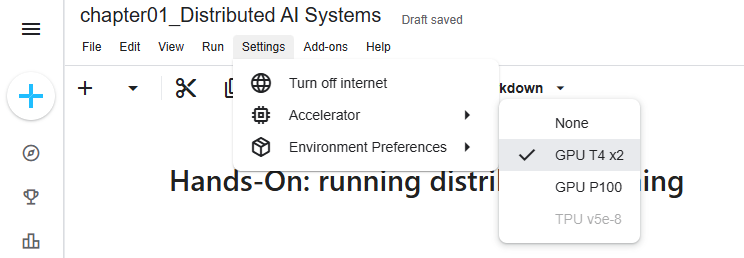

**GPU setup - 2 Tesla T4 GPUs**

In [2]:
!python /kaggle/working/Distributed-AI-Systems/chapter1-introduction-to-modern-distributed-ai/code/check_cuda.py

CUDA available: True
Number of GPUs: 2
GPU 0: Tesla T4 (14.6 GB)
GPU 1: Tesla T4 (14.6 GB)


In [3]:
!pip install -r /kaggle/working/Distributed-AI-Systems/chapter1-introduction-to-modern-distributed-ai/code/requirements.txt

**Single-GPU baseline**

In [4]:
!python /kaggle/working/Distributed-AI-Systems/chapter1-introduction-to-modern-distributed-ai/code/single_gpu_baseline.py

100%|██████████████████████████████████████| 26.4M/26.4M [00:02<00:00, 9.92MB/s]
100%|███████████████████████████████████████| 29.5k/29.5k [00:00<00:00, 143kB/s]
100%|██████████████████████████████████████| 4.42M/4.42M [00:01<00:00, 2.68MB/s]
100%|██████████████████████████████████████| 5.15k/5.15k [00:00<00:00, 25.3MB/s]
Epoch 1/3, Loss: 0.4169, Accuracy: 84.74%
Epoch 2/3, Loss: 0.2944, Accuracy: 89.18%
Epoch 3/3, Loss: 0.2549, Accuracy: 90.47%

Total training time: 68.31s


**Multi-GPU distributed training**

In [5]:
!torchrun --nproc_per_node=2 /kaggle/working/Distributed-AI-Systems/chapter1-introduction-to-modern-distributed-ai/code/multi_gpu_ddp.py

W0814 08:04:27.757000 100 torch/distributed/run.py:852] 
W0814 08:04:27.757000 100 torch/distributed/run.py:852] *****************************************
W0814 08:04:27.757000 100 torch/distributed/run.py:852] Setting OMP_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed. 
W0814 08:04:27.757000 100 torch/distributed/run.py:852] *****************************************
Epoch 1/3, Loss: 0.4248, Accuracy: 84.20%
Epoch 2/3, Loss: 0.2941, Accuracy: 89.16%
Epoch 3/3, Loss: 0.2473, Accuracy: 90.77%

Total training time: 40.04s


**Extended training: CIFAR-10 with 20 epochs**

**Run the single-GPU baseline:**

In [6]:
!python /kaggle/working/Distributed-AI-Systems/chapter1-introduction-to-modern-distributed-ai/code/single_gpu_extended.py --epochs 20

100%|████████████████████████████████████████| 170M/170M [34:17<00:00, 82.9kB/s]
Training ResNet18 on CIFAR-10 for 20 epochs...
Training samples: 50000, Test samples: 10000
------------------------------------------------------------
Epoch  1/20 | Loss: 1.3675 | Train Acc: 49.82% | Test Acc: 63.32% | LR: 0.001000
Epoch  2/20 | Loss: 0.8787 | Train Acc: 68.73% | Test Acc: 72.70% | LR: 0.001000
Epoch  3/20 | Loss: 0.6773 | Train Acc: 76.34% | Test Acc: 76.56% | LR: 0.001000
Epoch  4/20 | Loss: 0.5686 | Train Acc: 80.30% | Test Acc: 80.15% | LR: 0.001000
Epoch  5/20 | Loss: 0.4940 | Train Acc: 82.93% | Test Acc: 81.72% | LR: 0.001000
Epoch  6/20 | Loss: 0.4416 | Train Acc: 84.64% | Test Acc: 84.16% | LR: 0.001000
Epoch  7/20 | Loss: 0.3929 | Train Acc: 86.40% | Test Acc: 84.45% | LR: 0.000700
Epoch  8/20 | Loss: 0.3215 | Train Acc: 88.82% | Test Acc: 85.84% | LR: 0.000700
Epoch  9/20 | Loss: 0.2907 | Train Acc: 89.91% | Test Acc: 87.56% | LR: 0.000700
Epoch 10/20 | Loss: 0.2754 | Train Ac

> **Test distributed training (With 2 GPUs)**

In [7]:
!torchrun --nproc_per_node=2 /kaggle/working/Distributed-AI-Systems/chapter1-introduction-to-modern-distributed-ai/code/multi_gpu_ddp_extended.py --epochs 20

W0814 08:53:52.098000 911 torch/distributed/run.py:852] 
W0814 08:53:52.098000 911 torch/distributed/run.py:852] *****************************************
W0814 08:53:52.098000 911 torch/distributed/run.py:852] Setting OMP_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed. 
W0814 08:53:52.098000 911 torch/distributed/run.py:852] *****************************************
Training ResNet18 on CIFAR-10 for 20 epochs with 2 GPUs...
Training samples: 50000, Test samples: 10000
------------------------------------------------------------
Epoch  1/20 | Loss: 1.3843 | Train Acc: 49.21% | Test Acc: 56.34% | LR: 0.001000
Epoch  2/20 | Loss: 0.9170 | Train Acc: 67.33% | Test Acc: 66.80% | LR: 0.001000
Epoch  3/20 | Loss: 0.7027 | Train Acc: 75.30% | Test Acc: 75.90% | LR: 0.001000
Epoch  4/20 | Loss: 0.5979 | Train Acc: 79.07% | Test Acc: 77.10% | LR: 0

> **Distributed inference: throughput scaling**

> *Run the benchmarks. Start with the single-GPU baseline***

In [8]:
!python /kaggle/working/Distributed-AI-Systems/chapter1-introduction-to-modern-distributed-ai/code/single_gpu_inference.py --requests 1000

Processed 1000 requests in 3.82s
Time to finish 1000 requests: 3.82s
Throughput: 261.88 requests/second


> **test distributed inference with the data-split pattern (2 GPUs)**

In [9]:
!torchrun --nproc_per_node=2 /kaggle/working/Distributed-AI-Systems/chapter1-introduction-to-modern-distributed-ai/code/multi_gpu_inference.py --requests 1000

W0814 09:02:50.742000 2407 torch/distributed/run.py:852] 
W0814 09:02:50.742000 2407 torch/distributed/run.py:852] *****************************************
W0814 09:02:50.742000 2407 torch/distributed/run.py:852] Setting OMP_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed. 
W0814 09:02:50.742000 2407 torch/distributed/run.py:852] *****************************************
Processed 1000 requests across 2 GPUs in 2.57s
Time to finish 1000 requests: 2.57s
Throughput: 388.71 requests/second


**test distributed inference with request-split pattern (2 GPUs)**

In [10]:
!torchrun --nproc_per_node=2 /kaggle/working/Distributed-AI-Systems/chapter1-introduction-to-modern-distributed-ai/code/multi_gpu_inference_queue.py --requests 1000

W0814 09:03:02.645000 2468 torch/distributed/run.py:852] 
W0814 09:03:02.645000 2468 torch/distributed/run.py:852] *****************************************
W0814 09:03:02.645000 2468 torch/distributed/run.py:852] Setting OMP_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed. 
W0814 09:03:02.645000 2468 torch/distributed/run.py:852] *****************************************
[Request-Split Pattern] Processed 1000 requests across 2 GPUs in 3.67s
Time to finish 1000 requests: 3.67s
Throughput: 272.55 requests/second
Average latency per request: 3.67 ms
Requests per GPU: [500, 500]


# Distributed AI fundamentals with PyTorch

**Process Groups and Ranks**

> Initializing the process group

In [11]:
import torch.distributed as dist

def setup(rank, world_size):
    dist.init_process_group(
        backend="nccl",  # Use NCCL for GPU communication
        rank=rank,       # This process's rank
        world_size=world_size  # Total number of processes
    )
    torch.cuda.set_device(rank)  # Set which GPU this process uses

In [12]:
!OMP_NUM_THREADS=4 torchrun --nproc_per_node=2 /kaggle/working/Distributed-AI-Systems/chapter1-introduction-to-modern-distributed-ai/code/distributed_basic_test.py

Rank 0 says hello. GPU 0: Tesla T4 (14.6 GB)
Rank 1 says hello. GPU 1: Tesla T4 (14.6 GB)


> Test with multiple GPUs:

In [13]:
!torchrun --nproc_per_node=2 /kaggle/working/Distributed-AI-Systems/chapter1-introduction-to-modern-distributed-ai/code/distributed_basic_test.py


W0814 09:03:24.731000 2551 torch/distributed/run.py:852] 
W0814 09:03:24.731000 2551 torch/distributed/run.py:852] *****************************************
W0814 09:03:24.731000 2551 torch/distributed/run.py:852] Setting OMP_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed. 
W0814 09:03:24.731000 2551 torch/distributed/run.py:852] *****************************************
Rank 1 says hello. GPU 1: Tesla T4 (14.6 GB)
Rank 0 says hello. GPU 0: Tesla T4 (14.6 GB)


In [14]:
!OMP_NUM_THREADS=1 torchrun --nproc_per_node=2 /kaggle/working/Distributed-AI-Systems/chapter1-introduction-to-modern-distributed-ai/code/collective-operation/demo_allreduce.py



############################################################
PyTorch AllReduce Collective Operation Demo
Rank: 1, World Size: 2, Device: cuda:1
############################################################

############################################################
PyTorch AllReduce Collective Operation Demo
Rank: 0, World Size: 2, Device: cuda:0
############################################################

Demo: AllReduce (Rank 0)

Demo: AllReduce (Rank 1)
Rank 1 input: tensor([2., 3., 4.], device='cuda:1')
Rank 0 input: tensor([1., 2., 3.], device='cuda:0')
Rank 0 after all_reduce(SUM): tensor([3., 5., 7.], device='cuda:0')
Expected sum: 3 for each element
Rank 1 after all_reduce(SUM): tensor([3., 5., 7.], device='cuda:1')
Expected sum: 3 for each element
Rank 1 after all_reduce(MAX): tensor([2., 3., 4.], device='cuda:1')
Rank 0 after all_reduce(MAX): tensor([2., 3., 4.], device='cuda:0')
Rank 0 after all_reduce(MIN): tensor([1., 2., 3.], device='cuda:0')Rank 1 after all_reduce(MIN

In [15]:
!OMP_NUM_THREADS=1 torchrun --nproc_per_node=2 /kaggle/working/Distributed-AI-Systems/chapter1-introduction-to-modern-distributed-ai/code/collective-operation/demo_allgather.py



############################################################
############################################################

PyTorch AllGather Collective Operation DemoPyTorch AllGather Collective Operation Demo

Rank: 0, World Size: 2, Device: cuda:0
############################################################
Rank: 1, World Size: 2, Device: cuda:1
############################################################


Demo: AllGather (Rank 1)Demo: AllGather (Rank 0)


Rank 1 input: tensor([11., 12.], device='cuda:1')
Rank 0 input: tensor([1., 2.], device='cuda:0')
Rank 1 after all_gather: tensor([ 1.,  2., 11., 12.], device='cuda:1')
Expected: concatenation of [rank*10+1, rank*10+2] for all ranks
Rank 0 after all_gather: tensor([ 1.,  2., 11., 12.], device='cuda:0')
Expected: concatenation of [rank*10+1, rank*10+2] for all ranks

############################################################
############################################################

Rank 1: AllGather demo completed successful

In [16]:
!OMP_NUM_THREADS=1 torchrun --nproc_per_node=2 /kaggle/working/Distributed-AI-Systems/chapter1-introduction-to-modern-distributed-ai/code/collective-operation/demo_broadcast.py



############################################################
############################################################

PyTorch Broadcast Collective Operation DemoPyTorch Broadcast Collective Operation Demo

Rank: 0, World Size: 2, Device: cuda:0Rank: 1, World Size: 2, Device: cuda:1

########################################################################################################################



Demo: Broadcast (Rank 0)Demo: Broadcast (Rank 1)


Rank 1 before broadcast: tensor([0., 0., 0.], device='cuda:1')
Rank 0 (root) broadcasting: tensor([10., 20., 30.], device='cuda:0')
Rank 0 after broadcast: tensor([10., 20., 30.], device='cuda:0')
Rank 1 after broadcast: tensor([10., 20., 30.], device='cuda:1')

############################################################
Rank 1: Broadcast demo completed successfully!
############################################################

############################################################

Rank 0: Broadcast demo completed success

In [17]:
!OMP_NUM_THREADS=1 torchrun --nproc_per_node=2 /kaggle/working/Distributed-AI-Systems/chapter1-introduction-to-modern-distributed-ai/code/collective-operation/demo_reduce.py



############################################################
PyTorch Reduce Collective Operation Demo
Rank: 1, World Size: 2, Device: cuda:1
############################################################

############################################################
PyTorch Reduce Collective Operation Demo
Rank: 0, World Size: 2, Device: cuda:0
############################################################


Demo: Reduce (Rank 0)Demo: Reduce (Rank 1)

Rank 1 input: tensor([2., 3., 4.], device='cuda:1')
Rank 1 after reduce (unchanged): tensor([2., 3., 4.], device='cuda:1')
Rank 0 input: tensor([1., 2., 3.], device='cuda:0')
Rank 0 (root) after reduce: tensor([3., 5., 7.], device='cuda:0')
Expected sum: 3 for each element

############################################################
Rank 0: Reduce demo completed successfully!

############################################################
Rank 1: Reduce demo completed successfully!
############################################################
#

In [18]:
!OMP_NUM_THREADS=1 torchrun --nproc_per_node=2 /kaggle/working/Distributed-AI-Systems/chapter1-introduction-to-modern-distributed-ai/code/collective-operation/demo_gather.py



############################################################
PyTorch Gather Collective Operation Demo

############################################################Rank: 0, World Size: 2, Device: cuda:0

############################################################
PyTorch Gather Collective Operation Demo
Rank: 1, World Size: 2, Device: cuda:1
############################################################


Demo: Gather (Rank 0)
Demo: Gather (Rank 1)============================================================

Rank 1 input: tensor([11., 12.], device='cuda:1')
Rank 0 input: tensor([1., 2.], device='cuda:0')
Rank 0 (root) after gather: tensor([ 1.,  2., 11., 12.], device='cuda:0')
Rank 1 after gather (no output): input unchanged

############################################################
############################################################

Rank 1: Gather demo completed successfully!
Rank 0: Gather demo completed successfully!#######################################################

In [19]:
!OMP_NUM_THREADS=1 torchrun --nproc_per_node=2 /kaggle/working/Distributed-AI-Systems/chapter1-introduction-to-modern-distributed-ai/code/collective-operation/demo_scatter.py



############################################################
PyTorch Scatter Collective Operation Demo
Rank: 0, World Size: 2, Device: cuda:0
############################################################

############################################################
PyTorch Scatter Collective Operation Demo
Rank: 1, World Size: 2, Device: cuda:1
############################################################

Demo: Scatter (Rank 1)

Demo: Scatter (Rank 0)
Rank 0 (root) scattering: tensor([ 1.,  2., 11., 12.], device='cuda:0')
Rank 0 after scatter: tensor([1., 2.], device='cuda:0')
Expected: [rank*10 + 1, rank*10 + 2]
Rank 1 after scatter: tensor([11., 12.], device='cuda:1')
Expected: [rank*10 + 1, rank*10 + 2]

############################################################
############################################################

Rank 0: Scatter demo completed successfully!Rank 1: Scatter demo completed successfully!

############################################################
#########

In [20]:
!OMP_NUM_THREADS=1 torchrun --nproc_per_node=2 /kaggle/working/Distributed-AI-Systems/chapter1-introduction-to-modern-distributed-ai/code/collective-operation/demo_reducescatter.py



############################################################
############################################################

PyTorch ReduceScatter Collective Operation Demo
PyTorch ReduceScatter Collective Operation DemoRank: 1, World Size: 2, Device: cuda:1

############################################################
Rank: 0, World Size: 2, Device: cuda:0
############################################################

Demo: ReduceScatter (Rank 1)

Demo: ReduceScatter (Rank 0)
Rank 1 input: tensor([10., 11., 11., 12.], device='cuda:1')
Rank 0 input: tensor([0., 1., 1., 2.], device='cuda:0')
Rank 1 after reduce_scatter: tensor([12., 14.], device='cuda:1')
Expected: sum of i-th chunk from all ranks, where i=rank
Rank 0 after reduce_scatter: tensor([10., 12.], device='cuda:0')
Expected: sum of i-th chunk from all ranks, where i=rank

############################################################
Rank 0: ReduceScatter demo completed successfully!

##############################################

In [21]:
!OMP_NUM_THREADS=1 torchrun --nproc_per_node=2 /kaggle/working/Distributed-AI-Systems/chapter1-introduction-to-modern-distributed-ai/code/collective-operation/demo_alltoall.py



############################################################
PyTorch AlltoAll Collective Operation Demo

############################################################Rank: 0, World Size: 2, Device: cuda:0

PyTorch AlltoAll Collective Operation Demo
############################################################Rank: 1, World Size: 2, Device: cuda:1


############################################################Demo: AlltoAll (Rank 0)



Demo: AlltoAll (Rank 1)
Rank 1 input: tensor([101., 102., 111., 112.], device='cuda:1')
Rank 0 input: tensor([ 1.,  2., 11., 12.], device='cuda:0')
Rank 0 after all_to_all: tensor([  1.,   2., 101., 102.], device='cuda:0')Rank 1 after all_to_all: tensor([ 11.,  12., 111., 112.], device='cuda:1')

Expected: receives [src_rank*100 + rank*10 + 1, src_rank*100 + rank*10 + 2] from each src_rankExpected: receives [src_rank*100 + rank*10 + 1, src_rank*100 + rank*10 + 2] from each src_rank


############################################################

############

# Launching distributed jobs

In [22]:
!torchrun --nproc_per_node=2 /kaggle/working/Distributed-AI-Systems/chapter1-introduction-to-modern-distributed-ai/code/multi_gpu_ddp.py


W0814 09:04:37.017000 2781 torch/distributed/run.py:852] 
W0814 09:04:37.017000 2781 torch/distributed/run.py:852] *****************************************
W0814 09:04:37.017000 2781 torch/distributed/run.py:852] Setting OMP_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed. 
W0814 09:04:37.017000 2781 torch/distributed/run.py:852] *****************************************
Epoch 1/3, Loss: 0.4198, Accuracy: 84.54%
Epoch 2/3, Loss: 0.2916, Accuracy: 89.20%
Epoch 3/3, Loss: 0.2454, Accuracy: 90.95%

Total training time: 46.52s
